Saved plot to: /Users/antonbarslund/Documents/GitHub/Implementeringsprojekt/timings_plot.png


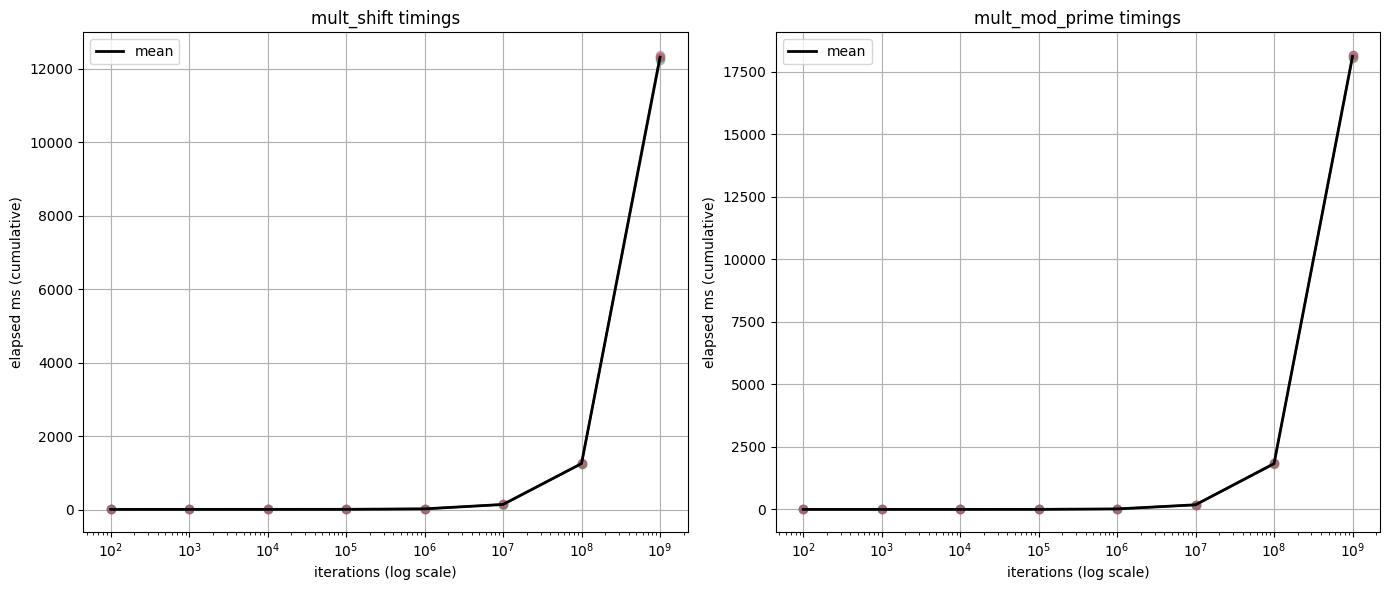

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

def load_runs(path):
    if not os.path.exists(path):
        return []
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith('//') or s.startswith('#'):
                continue
            idx = s.find(',')
            if idx == -1:
                continue
            it_str = s[:idx].strip()
            time_str = s[idx+1:].strip()
            # normalize decimal comma -> dot and remove extraneous spaces
            time_str = time_str.replace(' ', '').replace(',', '.')
            try:
                it = int(it_str)
                t = float(time_str)
                rows.append((it, t))
            except Exception:
                continue

    # split into runs when iteration does not increase
    runs = []
    curr = []
    prev_it = -1
    for it, t in rows:
        if prev_it != -1 and it <= prev_it:
            if curr:
                arr = np.array(curr)
                runs.append((arr[:,0].astype(int), arr[:,1].astype(float)))
            curr = []
        curr.append((it, t))
        prev_it = it
    if curr:
        arr = np.array(curr)
        runs.append((arr[:,0].astype(int), arr[:,1].astype(float)))
    return runs

def plot_runs(runs, title, ax):
    if not runs:
        ax.text(0.5, 0.5, 'No data', ha='center')
        ax.set_title(title)
        return
    # union of x for interpolation
    all_x = np.unique(np.concatenate([x for x, y in runs]))
    for x, y in runs:
        ax.plot(x, y, alpha=0.35, marker='o')
    interp = np.vstack([np.interp(all_x, x, y) for x, y in runs])
    mean = np.mean(interp, axis=0)
    ax.plot(all_x, mean, color='k', linewidth=2, label='mean')
    ax.set_xscale('log')
    ax.set_xlabel('iterations (log scale)')
    ax.set_ylabel('elapsed ms (cumulative)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

def main():
    base = '/Users/antonbarslund/Documents/GitHub/Implementeringsprojekt'
    shift_csv = os.path.join(base, 'mult_shift_times.csv')
    prime_csv = os.path.join(base, 'mult_mod_prime_times.csv')

    shift_runs = load_runs(shift_csv)
    prime_runs = load_runs(prime_csv)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
    plot_runs(shift_runs, 'mult_shift timings', ax1)
    plot_runs(prime_runs, 'mult_mod_prime timings', ax2)
    plt.tight_layout()
    out = os.path.join(base, 'timings_plot.png')
    plt.savefig(out, dpi=150)
    print('Saved plot to:', out)
    plt.show()

if __name__ == '__main__':
    main()

Saved: /Users/antonbarslund/Documents/GitHub/Implementeringsprojekt/compare_timings.png


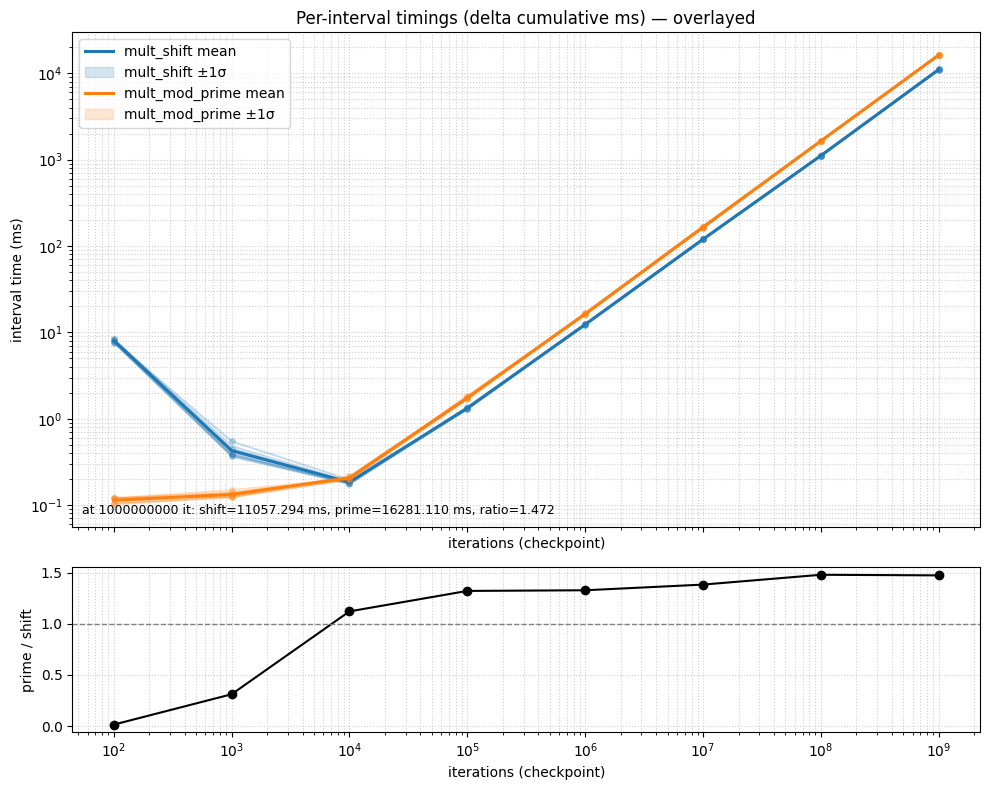

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = '/Users/antonbarslund/Documents/GitHub/Implementeringsprojekt'
SHIFT_CSV = os.path.join(BASE, 'mult_shift_times.csv')
PRIME_CSV = os.path.join(BASE, 'mult_mod_prime_times.csv')
OUT_PNG = os.path.join(BASE, 'compare_timings.png')

def read_runs(path):
    if not os.path.exists(path):
        return []
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for ln in f:
            s = ln.strip()
            if not s or s.startswith('//') or s.startswith('#'):
                continue
            idx = s.find(',')
            if idx == -1:
                continue
            it = s[:idx].strip()
            t = s[idx+1:].strip().replace(' ', '').replace(',', '.')
            try:
                rows.append((int(it), float(t)))
            except:
                continue
    # split into runs when iteration does not strictly increase
    runs = []
    curr = []
    prev = -1
    for it, t in rows:
        if prev != -1 and it <= prev:
            if curr:
                runs.append(pd.DataFrame(curr, columns=['it','ms']))
            curr = []
        curr.append((it,t))
        prev = it
    if curr:
        runs.append(pd.DataFrame(curr, columns=['it','ms']))
    return runs

def per_interval(df):
    df = df.sort_values('it').reset_index(drop=True)
    df['delta_ms'] = df['ms'].diff().fillna(df['ms'])   # first point = cumulative
    return df

def align_and_stats(runs):
    # runs: list of dataframes with columns it,ms
    if not runs:
        return None, None, None
    # collect all iteration points
    all_it = sorted({int(it) for r in runs for it in r['it'].values})
    interp_matrix = np.vstack([np.interp(all_it, r['it'], r['delta_ms']) for r in runs])
    mean = interp_matrix.mean(axis=0)
    std = interp_matrix.std(axis=0)
    return np.array(all_it), mean, std

shift_runs = read_runs(SHIFT_CSV)
prime_runs = read_runs(PRIME_CSV)

shift_runs = [per_interval(r) for r in shift_runs]
prime_runs = [per_interval(r) for r in prime_runs]

it_s, mean_s, std_s = align_and_stats(shift_runs)
it_p, mean_p, std_p = align_and_stats(prime_runs)

fig, (ax, axr) = plt.subplots(2, 1, figsize=(10,8), gridspec_kw={'height_ratios':[3,1]}, sharex=True)

# plot individual runs (faint) and mean with shading
def plot_group(ax, runs, it_common, mean, std, label, color):
    for r in runs:
        ax.plot(r['it'], r['delta_ms'], color=color, alpha=0.25, marker='o', linestyle='-', markersize=4)
    ax.plot(it_common, mean, color=color, linewidth=2.2, label=label + ' mean')
    ax.fill_between(it_common, mean-std, mean+std, color=color, alpha=0.18, label=label + ' ±1σ')

if it_s is not None:
    plot_group(ax, shift_runs, it_s, mean_s, std_s, 'mult_shift', '#1f77b4')
if it_p is not None:
    plot_group(ax, prime_runs, it_p, mean_p, std_p, 'mult_mod_prime', '#ff7f0e')

ax.set_xscale('log')
ax.set_yscale('log')  # per-interval times often vary; log makes comparison easier
ax.set_xlabel('iterations (checkpoint)')
ax.set_ylabel('interval time (ms)')
ax.set_title('Per-interval timings (delta cumulative ms) — overlayed')
ax.grid(True, which='both', ls=':', alpha=0.6)
ax.legend()

# ratio subplot (prime / shift)
if it_s is not None and it_p is not None:
    # interpolate means to common x (union)
    common_it = np.unique(np.concatenate([it_s, it_p]))
    ms_s = np.interp(common_it, it_s, mean_s)
    ms_p = np.interp(common_it, it_p, mean_p)
    ratio = ms_p / ms_s
    axr.plot(common_it, ratio, marker='o', color='k')
    axr.set_xscale('log')
    axr.set_xlabel('iterations (checkpoint)')
    axr.set_ylabel('prime / shift')
    axr.grid(True, which='both', ls=':', alpha=0.6)
    axr.axhline(1.0, color='gray', linestyle='--', linewidth=1)

# annotate summary numbers
def summary_text(mean_s, mean_p):
    if mean_s is None or mean_p is None:
        return ''
    # compare means at largest common checkpoint
    common_it = np.intersect1d(it_s, it_p)
    if common_it.size == 0:
        return ''
    max_it = common_it[-1]
    ms_s_last = float(np.interp(max_it, it_s, mean_s))
    ms_p_last = float(np.interp(max_it, it_p, mean_p))
    return f'at {max_it} it: shift={ms_s_last:.3f} ms, prime={ms_p_last:.3f} ms, ratio={ms_p_last/ms_s_last:.3f}'

txt = summary_text(mean_s, mean_p)
if txt:
    ax.text(0.01, 0.02, txt, transform=ax.transAxes, fontsize=9, va='bottom')

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150)
print('Saved:', OUT_PNG)
plt.show()